# Daniyal Khan || 221A061 || 19

Dataset shape: (150, 4)
Target classes: ['setosa' 'versicolor' 'virginica']


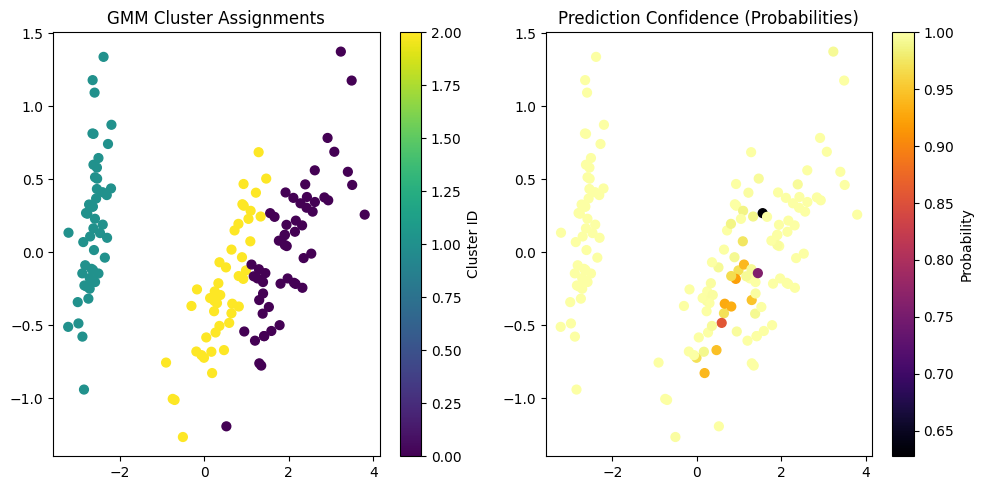

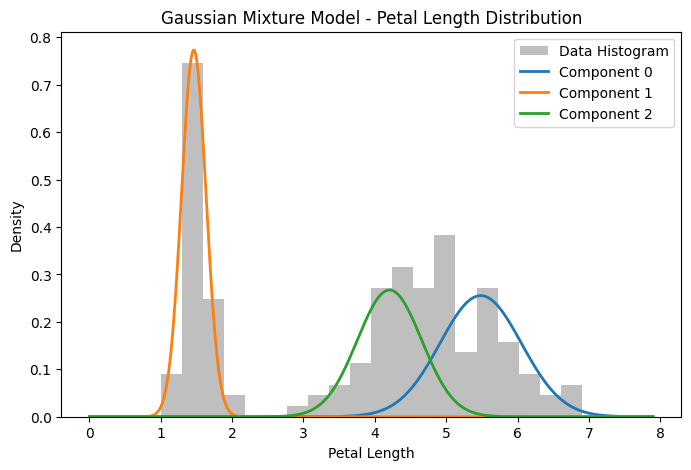


First 5 Sample Probabilities (Soft Clustering):
[[6.06216336e-35 1.00000000e+00 1.01178227e-43]
 [2.47801094e-28 1.00000000e+00 9.23008233e-31]
 [4.01248422e-30 1.00000000e+00 1.02746863e-35]
 [2.59713998e-26 1.00000000e+00 1.59307037e-31]
 [2.54371410e-35 1.00000000e+00 3.78557282e-46]]

Model Accuracy after label mapping: 96.67%


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from scipy.stats import mode


def main():
    # --------------------------------
    # Step 1: Load Real Dataset
    # --------------------------------
    iris = load_iris()
    X = iris.data
    y_true = iris.target

    print(f"Dataset shape: {X.shape}")
    print(f"Target classes: {iris.target_names}")

    # --------------------------------
    # Step 2: Apply GMM
    # --------------------------------
    gmm = GaussianMixture(
        n_components=3,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X)
    cluster_labels = gmm.predict(X)
    probabilities = gmm.predict_proba(X)

    # --------------------------------
    # Step 3: Align Clusters with Real Labels
    # --------------------------------
    labels = np.zeros_like(cluster_labels)

    for i in range(3):
        mask = (cluster_labels == i)
        labels[mask] = mode(y_true[mask], keepdims=True)[0]

    # --------------------------------
    # Step 4: PCA Visualization
    # --------------------------------
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 5))

    # Plot GMM Clusters
    plt.subplot(1, 2, 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1],
                c=cluster_labels, cmap='viridis', s=40)
    plt.title("GMM Cluster Assignments")
    plt.colorbar(label='Cluster ID')

    # Plot Soft Probabilities
    plt.subplot(1, 2, 2)
    max_probs = probabilities.max(axis=1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1],
                c=max_probs, cmap='inferno', s=40)
    plt.title("Prediction Confidence (Probabilities)")
    plt.colorbar(label='Probability')

    plt.tight_layout()
    plt.show()

    # --------------------------------
    # Step 5: Gaussian Curve Plot (1D)
    # --------------------------------
    feature_index = 2  # Petal Length
    x_feature = X[:, feature_index]

    x_range = np.linspace(
        x_feature.min() - 1,
        x_feature.max() + 1,
        500
    )

    plt.figure(figsize=(8, 5))

    # Histogram of actual data
    plt.hist(x_feature,
             bins=20,
             density=True,
             alpha=0.5,
             color='gray',
             label='Data Histogram')

    # Plot Gaussian components
    for i in range(gmm.n_components):
        mean = gmm.means_[i, feature_index]
        variance = gmm.covariances_[i][feature_index, feature_index]
        weight = gmm.weights_[i]

        gaussian_curve = (
            weight *
            (1 / np.sqrt(2 * np.pi * variance)) *
            np.exp(- (x_range - mean) ** 2 / (2 * variance))
        )

        plt.plot(x_range,
                 gaussian_curve,
                 linewidth=2,
                 label=f'Component {i}')

    plt.title("Gaussian Mixture Model - Petal Length Distribution")
    plt.xlabel("Petal Length")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    # --------------------------------
    # Step 6: Display Insights
    # --------------------------------
    print("\nFirst 5 Sample Probabilities (Soft Clustering):")
    print(probabilities[:5])

    accuracy = np.mean(labels == y_true)
    print(f"\nModel Accuracy after label mapping: {accuracy * 100:.2f}%")


if __name__ == "__main__":
    main()


Dataset shape: (150, 4)
Target classes: ['setosa' 'versicolor' 'virginica']


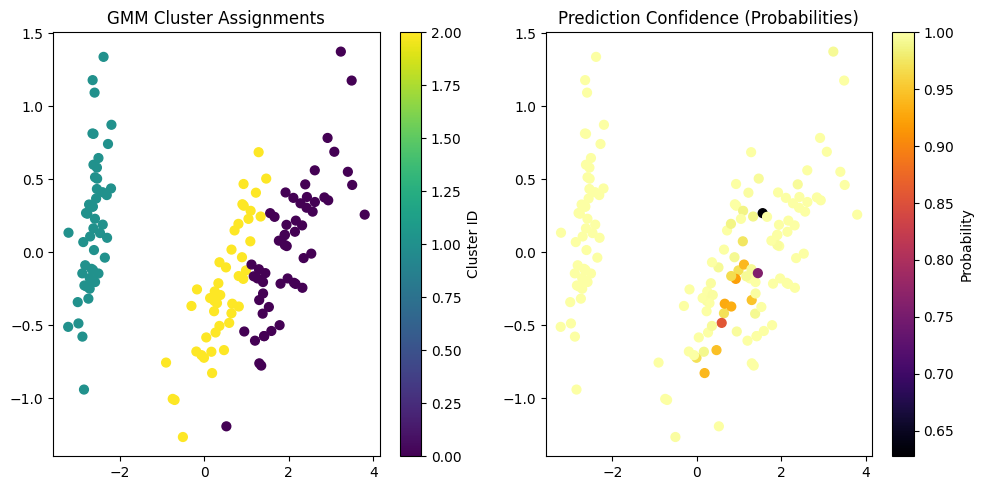

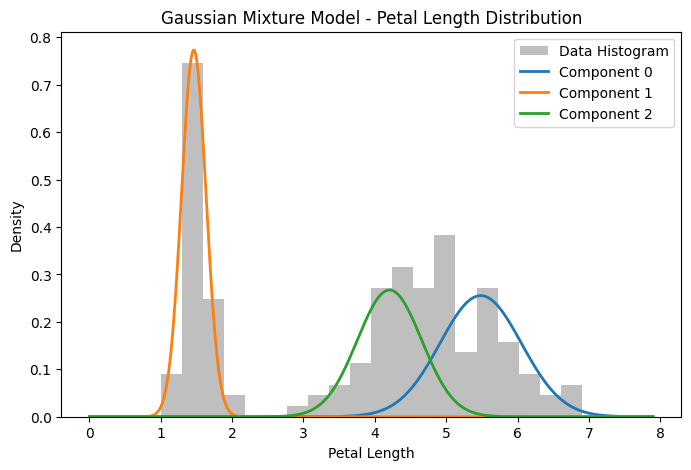


First 5 Sample Probabilities (Soft Clustering):
[[6.06216336e-35 1.00000000e+00 1.01178227e-43]
 [2.47801094e-28 1.00000000e+00 9.23008233e-31]
 [4.01248422e-30 1.00000000e+00 1.02746863e-35]
 [2.59713998e-26 1.00000000e+00 1.59307037e-31]
 [2.54371410e-35 1.00000000e+00 3.78557282e-46]]

Model Accuracy after label mapping: 96.67%


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from scipy.stats import mode


def main():
    iris = load_iris()
    X = iris.data
    y_true = iris.target

    print(f"Dataset shape: {X.shape}")
    print(f"Target classes: {iris.target_names}")

    gmm = GaussianMixture(
        n_components=3,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X)
    cluster_labels = gmm.predict(X)
    probabilities = gmm.predict_proba(X)

    labels = np.zeros_like(cluster_labels)
    for i in range(3):
        mask = (cluster_labels == i)
        labels[mask] = mode(y_true[mask], keepdims=True)[0]

    # PCA Visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1],
                c=cluster_labels, cmap='viridis', s=40)
    plt.title("GMM Cluster Assignments")
    plt.colorbar(label='Cluster ID')

    plt.subplot(1, 2, 2)
    max_probs = probabilities.max(axis=1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1],
                c=max_probs, cmap='inferno', s=40)
    plt.title("Prediction Confidence (Probabilities)")
    plt.colorbar(label='Probability')

    plt.tight_layout()
    plt.show()

    # Gaussian Curve Plot (1D - Petal Length)
    feature_index = 2
    x_feature = X[:, feature_index]

    x_range = np.linspace(
        x_feature.min() - 1,
        x_feature.max() + 1,
        500
    )

    plt.figure(figsize=(8, 5))

    plt.hist(x_feature,
             bins=20,
             density=True,
             alpha=0.5,
             color='gray',
             label='Data Histogram')

    for i in range(gmm.n_components):
        mean = gmm.means_[i, feature_index]
        variance = gmm.covariances_[i][feature_index, feature_index]
        weight = gmm.weights_[i]

        gaussian_curve = (
            weight *
            (1 / np.sqrt(2 * np.pi * variance)) *
            np.exp(- (x_range - mean) ** 2 / (2 * variance))
        )

        plt.plot(x_range,
                 gaussian_curve,
                 linewidth=2,
                 label=f'Component {i}')

    plt.title("Gaussian Mixture Model - Petal Length Distribution")
    plt.xlabel("Petal Length")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    print("\nFirst 5 Sample Probabilities (Soft Clustering):")
    print(probabilities[:5])

    accuracy = np.mean(labels == y_true)
    print(f"\nModel Accuracy after label mapping: {accuracy * 100:.2f}%")


if __name__ == "__main__":
    main()
